Title : Fabric Defect Detection Dataset Audit

Objective : To go throught the whole dataset and find all the required Information to answer those belowe questions successfully to decide wheather it's worthy for taking to our AI model Training
1. How many images are available ? 
2. what classes exist ? 
3. are all images the same size ? 
4. are there duplicate images ?
5. do mask images matches the original images
6. are there corrupted files ?
7. what potential issues exist in the dataset ?
8. are all images in dataset binary(black and white)?

Outcomes : after a successful audit we'll able to asnwer those question and decide if the dataset is trustworthy for training the AI model . 

In [213]:
from pathlib import Path

In [214]:
project_root = Path("..") #To point to the root folder of the project
dataset_path = project_root / "dataset" #to point the main dataaset folder
print(dataset_path)
print(dataset_path.exists()) #checking validity

../dataset
True


In [215]:
for item in dataset_path.iterdir(): #it loops through the next one directories
    if   item.is_dir():
        print(item)
    

../dataset/hole
../dataset/verticle
../dataset/horizontal
../dataset/captured


In [216]:
content = {} #dictionary to gather the image formats info

for item in dataset_path.rglob("*"): #rglob is a function that go till the last file/dir in a path and traverse them all and returned them all
    if item.is_file():

        if item.suffix.lower() in content:
            content[item.suffix.lower()] += 1

        else:
            content[item.suffix.lower()] = 1

print(content)

{'.jpg': 666}


In [217]:
from PIL import Image
first_image = next(dataset_path.rglob("*.jpg")) #next return the first file return by rglob
image = Image.open(first_image)  #making this a object of Image to conduct some operation on it
print(first_image)
print(image.size, image.mode, image.format) #some properties of images


../dataset/hole/17_processed (1).jpg
(640, 360) L JPEG


In [218]:
#collecting some more info about our dataset
image_info_size = {}
image_info_mode = {}
image_info_format = {}
for item in dataset_path.rglob("*.jpg"):
    temp_img = Image.open(item)
    if temp_img.size in image_info_size:
        image_info_size[(temp_img.size)] += 1
    else:
        image_info_size[temp_img.size] = 1
    if temp_img.mode in image_info_mode:
        image_info_mode[temp_img.mode] += 1
    else : 
        image_info_mode[temp_img.mode] = 1
    if temp_img.format in image_info_format:
        image_info_format[temp_img.format] += 1
    else:
        image_info_format[temp_img.format] = 1
print(f"image size : {image_info_size} \n image format : {image_info_format} \n image mode : {image_info_mode}")



image size : {(640, 360): 412, (1280, 720): 232, (4608, 3456): 22} 
 image format : {'JPEG': 666} 
 image mode : {'L': 309, 'RGB': 357}


In [219]:
IGNORE_DIRS = {"captured"} #all the dir that's not the training data for my project/program
#the reason behind making IGNORE_DIRS is a set -> to filter out the same named dir in the list

class_names = []
for dir in dataset_path.iterdir():
    if dir.is_dir() and dir.name not in IGNORE_DIRS:
        class_names.append(dir.name)
print(class_names)
class_to_idx = {}
for index,label in enumerate(class_names,0):
    if label not in class_to_idx:
        class_to_idx[label] = index

print(class_to_idx)

    


['hole', 'verticle', 'horizontal']
{'hole': 0, 'verticle': 1, 'horizontal': 2}


In [220]:
## Build (image_path, label) pairs for the dataset
##and this will be the training data the model see a image and remember it's label
samples = [] ## Store all dataset samples
for class_name in class_to_idx:
    item_path = dataset_path / class_name ## Path to the current class directory
    for image_path in item_path.iterdir(): ## Iterate over files instead of assuming only .jpg images exist
        # with Image.open(image_path) as temp: ## Open the image to verify its format
        #     if temp.format in image_info_format: 
        #### The dataset audit confirmed that all images are JPEG files.
        samples.append((image_path,class_to_idx[class_name]))
print(samples)


[(PosixPath('../dataset/hole/17_processed (1).jpg'), 0), (PosixPath('../dataset/hole/28_processed (3).jpg'), 0), (PosixPath('../dataset/hole/23_processed (3).jpg'), 0), (PosixPath('../dataset/hole/35_processed (1).jpg'), 0), (PosixPath('../dataset/hole/15_processed (2).jpg'), 0), (PosixPath('../dataset/hole/38.jpg'), 0), (PosixPath('../dataset/hole/5_processed (3).jpg'), 0), (PosixPath('../dataset/hole/28.jpg'), 0), (PosixPath('../dataset/hole/37_processed (2).jpg'), 0), (PosixPath('../dataset/hole/31_processed (3).jpg'), 0), (PosixPath('../dataset/hole/22_processed (2).jpg'), 0), (PosixPath('../dataset/hole/15.jpg'), 0), (PosixPath('../dataset/hole/24_processed (1).jpg'), 0), (PosixPath('../dataset/hole/38_processed (1).jpg'), 0), (PosixPath('../dataset/hole/22_processed (1).jpg'), 0), (PosixPath('../dataset/hole/10.jpg'), 0), (PosixPath('../dataset/hole/44_processed (2).jpg'), 0), (PosixPath('../dataset/hole/34_processed (3).jpg'), 0), (PosixPath('../dataset/hole/37.jpg'), 0), (Posix

In [221]:
class_distribution = {}  #to determine the balance
for sample in samples:
    if sample[1] in class_distribution:
        class_distribution[sample[1]] += 1
    else:
        class_distribution[sample[1]] = 1
print(class_distribution)


{0: 184, 1: 92, 2: 136}


In [222]:
#look up on final analysis
for class_name, label in class_to_idx.items():
    print(f"{class_name:<12}: {class_distribution[label]}")

hole        : 184
verticle    : 92
horizontal  : 136


In [223]:
import numpy as np #basic of numpy
image_location = samples[0][0]
img = Image.open(image_location)
image_array = np.array(img)
print(type(image_array))
print(image_array.size)
print(image_array.shape)
print(image_array.dtype)
print(image_array)
print(image_array[-1][639])
print(image_array[359][639])

<class 'numpy.ndarray'>
230400
(360, 640)
uint8
[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 252 252]
 [  0   0   0 ... 255 255 255]]
255
255


In [224]:
for image_path,label in samples: #checked the difference of RGB and Grayscale images
    with Image.open(image_path) as image:
        if image.mode == "RGB":
            image_array = np.array(image)
            print(image_array.shape)
            print(image_array.dtype)
            break   

(360, 640, 3)
uint8


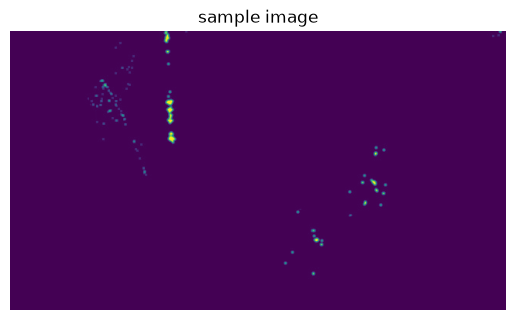

In [225]:
import matplotlib.pyplot as plt # Entering into matplotlib with basics
image_path = samples[200][0]
with Image.open(image_path) as image:
    plt.imshow(image)
    plt.axis("off")
    plt.title("sample image")
    plt.show()

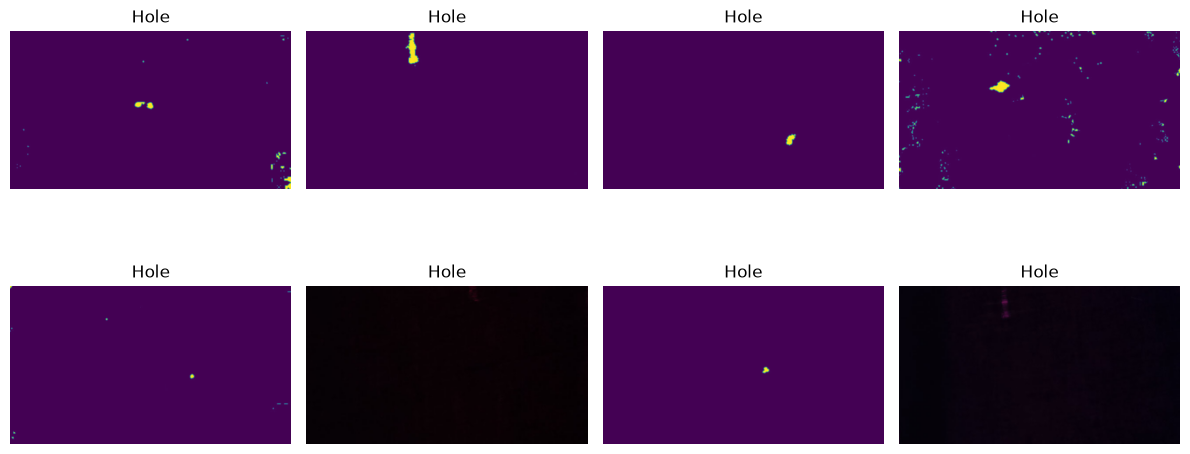

In [235]:
plt.figure(figsize=(12, 6))
for i,(image_path,label) in enumerate(samples[:8],start=1):
    plt.subplot(2,4,i)
    with Image.open(image_path) as image:
        plt.imshow(image)
    for class_name in class_to_idx:
        if label == class_to_idx[class_name]:
            name = class_name
        
    plt.title(name.capitalize())
    plt.axis("off")
plt.tight_layout()
plt.show()




In [227]:
for index in class_to_idx:
    print(class_to_idx[index])

0
1
2
